In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import zipfile

zip_path = "/content/drive/MyDrive/archive (1).zip"
extract_path = "/content/drive/MyDrive/loan_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier

import shap
import joblib

In [4]:
import pandas as pd

file_path = "/content/drive/MyDrive/loan_data/loan.csv"
dataset = pd.read_csv(file_path, low_memory=False)

print(dataset.shape)

(2260668, 145)


In [5]:
dataset['loan_status'].value_counts()

,count
loan_status,
Fully Paid,1041952
Current,919695
Charged Off,261655
Late (31-120 days),21897
In Grace Period,8952
Late (16-30 days),3737
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,31


In [6]:
print(dataset.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_i

In [7]:
# Keep only Fully Paid and Charged Off
dataset = dataset[dataset["loan_status"].isin(["Fully Paid", "Charged Off"])]

# Convert target variable
dataset["target"] = dataset["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

print(dataset["target"].value_counts())


target
0    1041952
1     261655
Name: count, dtype: int64


In [8]:
loan_features = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "purpose",
    "application_type"
]

In [9]:
borrower_features = [
    "annual_inc",
    "dti",
    "verification_status",
    "home_ownership",
    "emp_length"
]

In [10]:
behavior_features = [
    "acc_now_delinq",
    "num_accts_ever_120_pd",
    "num_tl_30dpd",
    "num_tl_90g_dpd_24m",
    "pct_tl_nvr_dlq",
    "percent_bc_gt_75",
    "bc_util",
    "delinq_2yrs",
    "inq_last_6mths"
]

In [11]:
credit_structure_features = [
    "open_acc",
    "total_acc",
    "mort_acc",
    "pub_rec",
    "pub_rec_bankruptcies"
]

In [12]:
limit_features = [
    "revol_bal",
    "revol_util",
    "tot_hi_cred_lim",
    "total_bal_ex_mort",
    "total_bc_limit",
    "total_rev_hi_lim",
    "avg_cur_bal",
    "il_util",
    "max_bal_bc"
]

In [13]:
important_features = (
    loan_features +
    borrower_features +
    behavior_features +
    credit_structure_features +
    limit_features
)


In [14]:
df=dataset[important_features+['target']]

In [15]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
purpose,0
application_type,0
annual_inc,0
dti,312


In [16]:
null_percent = df.isnull().mean() * 100
print(null_percent.sort_values(ascending=False))

il_util                  66.809936
max_bal_bc               61.679785
emp_length                5.788094
pct_tl_nvr_dlq            5.191825
avg_cur_bal               5.181623
tot_hi_cred_lim           5.180012
total_rev_hi_lim          5.180012
num_accts_ever_120_pd     5.180012
num_tl_90g_dpd_24m        5.180012
num_tl_30dpd              5.180012
bc_util                   4.708935
percent_bc_gt_75          4.682930
total_bc_limit            3.626937
mort_acc                  3.626937
total_bal_ex_mort         3.626937
revol_util                0.062135
pub_rec_bankruptcies      0.053467
dti                       0.023934
inq_last_6mths            0.000077
loan_amnt                 0.000000
term                      0.000000
grade                     0.000000
installment               0.000000
int_rate                  0.000000
purpose                   0.000000
annual_inc                0.000000
application_type          0.000000
verification_status       0.000000
home_ownership      

In [17]:
df["term"] = df["term"].str.extract("(\d+)").astype(int)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_896/2372863020.py:1: SyntaxWarning: invalid escape sequence '\d'
  df["term"] = df["term"].str.extract("(\d+)").astype(int)
/tmp/ipykernel_896/2372863020.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["term"] = df["term"].str.extract("(\d+)").astype(int)


In [18]:

df.replace([np.inf, -np.inf], np.nan, inplace=True)

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())



cat_cols = df.select_dtypes(include="object").columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

/tmp/ipykernel_896/2466115845.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_896/2466115845.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[num_cols] = df[num_cols].fillna(df[num_cols].median())
/tmp/ipykernel_896/2466115845.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#re

In [19]:
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
purpose,0
application_type,0
annual_inc,0
dti,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303607 entries, 100 to 2260664
Data columns (total 37 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   loan_amnt              1303607 non-null  int64  
 1   term                   1303607 non-null  int64  
 2   int_rate               1303607 non-null  float64
 3   installment            1303607 non-null  float64
 4   grade                  1303607 non-null  object 
 5   sub_grade              1303607 non-null  object 
 6   purpose                1303607 non-null  object 
 7   application_type       1303607 non-null  object 
 8   annual_inc             1303607 non-null  float64
 9   dti                    1303607 non-null  float64
 10  verification_status    1303607 non-null  object 
 11  home_ownership         1303607 non-null  object 
 12  emp_length             1303607 non-null  object 
 13  acc_now_delinq         1303607 non-null  float64
 14  num_accts_ever_120_pd

In [21]:
df["annual_inc"] = np.log1p(df["annual_inc"])
df["loan_amnt"] = np.log1p(df["loan_amnt"])
df["revol_util"] = np.log1p(df["revol_util"])

/tmp/ipykernel_896/1840280064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["annual_inc"] = np.log1p(df["annual_inc"])
/tmp/ipykernel_896/1840280064.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["loan_amnt"] = np.log1p(df["loan_amnt"])
/tmp/ipykernel_896/1840280064.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

In [22]:
df["annual_inc"] = df["annual_inc"].replace(0, 1)

df["loan_income_ratio"] = df["loan_amnt"] / df["annual_inc"]
df["installment_income_ratio"] = df["installment"] / df["annual_inc"]
df["loan_income_ratio"] = df["loan_amnt"] / df["annual_inc"]
df["installment_income_ratio"] = df["installment"] / df["annual_inc"]

/tmp/ipykernel_896/1786942381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["annual_inc"] = df["annual_inc"].replace(0, 1)
/tmp/ipykernel_896/1786942381.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["loan_income_ratio"] = df["loan_amnt"] / df["annual_inc"]
/tmp/ipykernel_896/1786942381.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas

In [23]:
df["total_credit_stress"] = df["revol_bal"] / df["tot_hi_cred_lim"]

/tmp/ipykernel_896/2968989990.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["total_credit_stress"] = df["revol_bal"] / df["tot_hi_cred_lim"]


In [24]:
df["delinquency_score"] = (
    df["num_tl_90g_dpd_24m"] * 3 +
    df["num_tl_30dpd"] * 2 +
    df["acc_now_delinq"] * 1
)


/tmp/ipykernel_896/2227324860.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["delinquency_score"] = (


In [25]:
df["active_account_ratio"] = df["open_acc"] / df["total_acc"]

/tmp/ipykernel_896/3189735407.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["active_account_ratio"] = df["open_acc"] / df["total_acc"]


In [26]:
df["high_util_flag"] = (df["revol_util"] > 80).astype(int)


/tmp/ipykernel_896/2917789405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["high_util_flag"] = (df["revol_util"] > 80).astype(int)


In [27]:
import pandas as pd

# Show all columns
pd.set_option('display.max_columns', None)

# Show full width
pd.set_option('display.width', None)

# Show full column content
pd.set_option('display.max_colwidth', None)
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,purpose,application_type,annual_inc,dti,verification_status,home_ownership,emp_length,acc_now_delinq,num_accts_ever_120_pd,num_tl_30dpd,num_tl_90g_dpd_24m,pct_tl_nvr_dlq,percent_bc_gt_75,bc_util,delinq_2yrs,inq_last_6mths,open_acc,total_acc,mort_acc,pub_rec,pub_rec_bankruptcies,revol_bal,revol_util,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_rev_hi_lim,avg_cur_bal,il_util,max_bal_bc,target,loan_income_ratio,installment_income_ratio,total_credit_stress,delinquency_score,active_account_ratio,high_util_flag
100,10.308986,36,22.35,1151.16,D,D5,debt_consolidation,Joint App,11.512935,30.46,Source Verified,MORTGAGE,5 years,0.0,0.0,0.0,0.0,89.5,33.3,46.9,0.0,0.0,11.0,19.0,1.0,1.0,1.0,15603,3.637586,527120.0,98453.0,28600.0,42200.0,42939.0,75.0,9713.0,0,0.895426,99.988400,0.029600,0.0,0.578947,0
152,10.596660,60,16.14,975.71,C,C4,credit_card,Joint App,10.714440,50.53,Verified,MORTGAGE,< 1 year,0.0,0.0,0.0,0.0,100.0,42.9,67.3,0.0,0.0,18.0,37.0,1.0,0.0,0.0,34971,4.182050,344802.0,161720.0,45700.0,54200.0,15059.0,87.0,5874.0,0,0.989007,91.064955,0.101423,0.0,0.486486,0
170,9.903538,36,7.56,622.68,A,A3,credit_card,Joint App,11.512935,18.92,Not Verified,MORTGAGE,10+ years,0.0,0.0,0.0,0.0,94.7,20.0,29.9,0.0,0.0,9.0,19.0,5.0,0.0,0.0,25416,3.430756,622183.0,71569.0,85100.0,85100.0,57309.0,71.0,9759.0,0,0.860210,54.085251,0.040850,0.0,0.473684,0
186,8.412055,36,11.31,147.99,B,B3,credit_card,Individual,10.558439,4.64,Not Verified,RENT,10+ years,0.0,1.0,0.0,0.0,91.7,0.0,28.9,0.0,0.0,12.0,25.0,0.0,0.0,0.0,4472,2.791165,53795.0,29137.0,15100.0,29200.0,2428.0,100.0,3612.0,0,0.796714,14.016276,0.083130,0.0,0.480000,0
215,9.039077,36,27.27,345.18,E,E5,credit_card,Joint App,13.017005,12.37,Verified,MORTGAGE,3 years,0.0,0.0,0.0,0.0,100.0,50.0,74.6,0.0,0.0,21.0,37.0,4.0,0.0,0.0,36812,4.200205,768304.0,189194.0,45800.0,56000.0,34516.0,70.0,9744.0,0,0.694405,26.517620,0.047913,0.0,0.567568,0


In [28]:
df['emp_length'].value_counts()

,count
emp_length,
10+ years,428547
2 years,117820
< 1 year,104550
3 years,104200
1 year,85677
5 years,81623
4 years,78029
Unknown,75454
6 years,60933


In [29]:
X = df.drop("target", axis=1)
y = df["target"]

In [30]:
categorical_features = [
    "term",
    "grade",
    "sub_grade",
    "purpose",
    "application_type",
    "verification_status",
    "home_ownership",
    "emp_length"
]

numeric_features = X.drop(columns=categorical_features).columns

In [31]:

preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(scale_pos_weight)

3.9821568477575435


In [34]:
model = XGBClassifier(

    n_estimators=600,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42
)

pipeline = Pipeline(

    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [35]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
       'acc_now_delinq', 'num_accts_ever_120_pd', 'num_tl_30dpd',
       'num_tl_90g_dpd_24m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'bc_util',
       'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc', 'mort_acc',
       'pub_rec', '...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=600,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [36]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.89      0.65      0.75    208391
           1       0.33      0.67      0.44     52331

    accuracy                           0.66    260722
   macro avg       0.61      0.66      0.60    260722
weighted avg       0.78      0.66      0.69    260722

ROC-AUC: 0.724619730576648


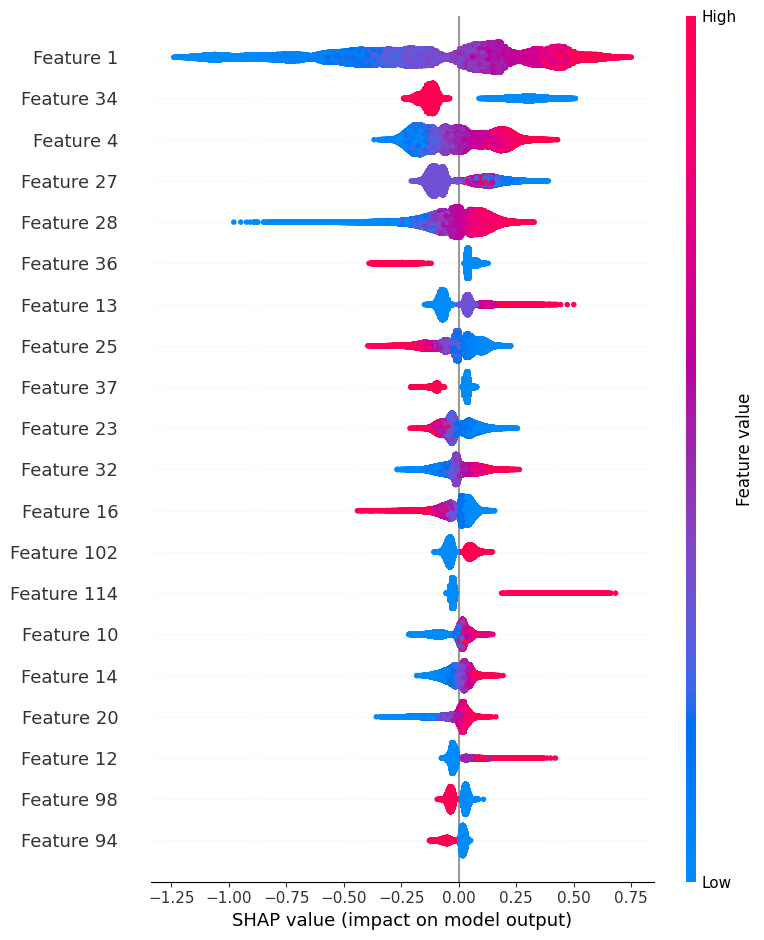

In [37]:
explainer = shap.Explainer(pipeline["model"])

X_processed = pipeline["preprocessor"].transform(X_test)

shap_values = explainer(X_processed)

shap.summary_plot(shap_values, X_processed)

In [38]:
import pickle


with open("loan_model_1.pkl", "wb") as f:
    pickle.dump(pipeline, f)


In [39]:

with open("model_features1.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)